# Reranking Goldilocks: TechQA (RAGBench)

Same reranking search methodology as `delucion_dataset/14_reranking_goldilocks.ipynb`,
applied to TechQA on top of `11`, `12`, and `13`'s real TechQA winners:

- **Chunking** (`11`): recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap (composite 0.401)
- **Retriever** (`12`): hybrid (BM25 + dense), alpha=0.5 -- the untuned default, since `12`'s
  own alpha sweep found no hand-tuned value that reproducibly beat it
- **Query transformation** (`13`): HyDE, **three** hypothetical documents concatenated with
  the original query, driving retrieval only -- notably *not* DelucionQA's winning
  single-document HyDE config. `13`'s TechQA analysis found more hypothetical documents
  helps here, the opposite of DelucionQA, and replicates the source paper's own TREC DL
  finding that DelucionQA didn't reproduce.

Reranking is this notebook's own independent variable. Same rigor throughout: fixed
20-question evaluation set reused across every config, judge annotation retries, and the
same composite score (0.35·Relevance + 0.15·Utilization + 0.15·Completeness +
0.35·Adherence) for comparability across datasets.

Worth restating from `12` and `13`'s own analyses: TechQA's noise floor is larger than
DelucionQA's -- nominally identical configs have scored composite differences as large as
0.07 across independent runs in this series so far. Composite differences smaller than
roughly that magnitude in this notebook should be read as directional, not decisive.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    """ragbench_lib physically lives under delucion_dataset/ -- shared, not
    duplicated, across every dataset folder in this repo."""
    here = os.getcwd()
    candidates = (
        here,
        os.path.join(here, "delucion_dataset"),
        os.path.join(os.path.dirname(here), "delucion_dataset"),
        os.path.join(here, "..", "delucion_dataset"),
    )
    for candidate in candidates:
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return
    raise RuntimeError("Could not locate the shared ragbench_lib package (expected under delucion_dataset/).")


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

Same fixed-sample mechanism as `11`/`12`/`13` -- `EVAL_SAMPLE_SIZE` questions chosen once,
up front, and reused for every config in every phase below.

In [3]:
DATASET_NAME = "techqa"  # RAGBench's tech-forum Q&A config
EVAL_SAMPLE_SIZE = 20

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 150 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: Fixed Chunking + Retrieval + Query-Transformation Foundation

Every layer below this notebook's own variable is frozen at TechQA's actual winning config:

- **Chunking**: recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap (`11`)
- **Retriever**: hybrid (BM25 + dense), alpha=0.5 (`12`) -- built once at a wide k so every
  phase below can slice smaller candidate pools out of the same ranked list without
  rebuilding the vector store or re-embedding anything
- **Query transformation**: HyDE, **three** hypothetical documents concatenated with the
  original query, driving retrieval only -- the generator (and the reranker, see Step 6)
  always see the original question (`13`)

Reranking is the only independent variable in this notebook.

In [5]:
CHUNK_TARGET_TOKENS = 128
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.5
MAX_CANDIDATE_K = 40  # widest candidate pool any phase below will request


def recursive_character_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """LangChain's standard RecursiveCharacterTextSplitter -- 11's TechQA winner.
    ~4 chars/token heuristic converts the token budget into the character-based
    splitter's units."""
    chunk_size_chars = target_tokens * 4
    overlap_chars = int(chunk_size_chars * overlap_fraction)
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_chars, chunk_overlap=overlap_chars)
    documents = []
    for _, doc in docs_df.iterrows():
        for chunk_idx, chunk_text in enumerate(splitter.split_text(doc["text"])):
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_rc{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
    return documents


def apply_hyde(query, llm, n_docs=3, concat_with_query=True):
    """Winning HyDE config from 13: 3 hypothetical docs, concatenated with the
    query, used to drive retrieval only."""
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


print("Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...")
documents = recursive_character_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print(f"Building wide hybrid retriever foundation (alpha=0.5, k={MAX_CANDIDATE_K})...")
wide_retriever = HybridRetriever(documents, embedding_model, k=MAX_CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                  dataset_name=DATASET_NAME, config_name="rerank_foundation")
print("✓ Wide hybrid retriever ready -- every phase below slices its candidate pool out of this ranked list")


def get_candidates(retrieval_query, candidate_k):
    """Top candidate_k docs from the wide hybrid retriever's ranked list. Slicing a
    prefix of the top-MAX_CANDIDATE_K ranking is equivalent to querying with
    k=candidate_k directly (both are the same descending sort by combined score), so
    this reuses one embedding pass across every candidate_k tested below."""
    return wide_retriever.retrieve(retrieval_query)[:candidate_k]


Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...
✓ Built 1649 chunks, avg 90 tokens/chunk
Building wide hybrid retriever foundation (alpha=0.5, k=40)...
✓ Wide hybrid retriever ready -- every phase below slices its candidate pool out of this ranked list


## Step 6: Reranker Implementations

`NoReranker` is the control: it keeps the hybrid+HyDE ranking as-is and just truncates to
`top_k`. The three OpenRouter cross-encoder rerankers (`08`'s own selection, reused
verbatim) rescore the candidate pool against the **original** question -- not the HyDE
retrieval string -- since reranking's job is to judge relevance to what the user actually
asked, and the pseudo-document was only ever meant to widen retrieval's net.

In [6]:
class NoReranker:
    """Control: keep the hybrid+HyDE candidate ranking, just truncate."""
    def rerank(self, query, documents, top_k):
        return documents[:top_k]


class OpenRouterReranker:
    """Cross-encoder reranking via OpenRouter's dedicated /api/v1/rerank endpoint."""

    def __init__(self, model_name, api_key):
        self.model_name = model_name
        self.api_key = api_key
        self.endpoint = "https://openrouter.ai/api/v1/rerank"

    def rerank(self, query, documents, top_k):
        if not documents:
            return documents
        doc_texts = [d.page_content for d in documents]
        headers = {"Authorization": f"Bearer {self.api_key}", "Content-Type": "application/json"}
        payload = {"model": self.model_name, "query": query, "documents": doc_texts, "top_n": top_k}
        try:
            response = requests.post(self.endpoint, headers=headers, json=payload, timeout=30)
            response.raise_for_status()
            result = response.json()
            if "results" in result:
                ranked = sorted(result["results"], key=lambda r: r.get("relevance_score", 0), reverse=True)
                indices = [r["index"] for r in ranked[:top_k]]
                return [documents[i] for i in indices]
            return documents[:top_k]
        except Exception as e:
            print(f"    [DEBUG] rerank error ({self.model_name}): {str(e)[:60]}")
            return documents[:top_k]


RERANKER_BUILDERS = {
    "no_rerank": lambda: NoReranker(),
    "cohere_v35": lambda: OpenRouterReranker("cohere/rerank-v3.5", openrouter_token),
    "cohere_4pro": lambda: OpenRouterReranker("cohere/rerank-4-pro", openrouter_token),
    "nvidia_nemotron": lambda: OpenRouterReranker("nvidia/llama-nemotron-rerank-vl-1b-v2:free", openrouter_token),
}

print("✓ Reranker implementations ready (no_rerank, cohere_v35, cohere_4pro, nvidia_nemotron)")


✓ Reranker implementations ready (no_rerank, cohere_v35, cohere_4pro, nvidia_nemotron)


## Step 7: Evaluation Runner

Every config runs the fixed 20-question set through: HyDE-transform the query -> retrieve
`candidate_k` hybrid-ranked candidates -> rerank against the **original** question, keeping
`final_k` -> generate from the original question (per `13`'s finding that the generator
should never see the transformed string) -> retry judge annotation up to 3x -> compute
TRACe metrics + the same composite score `11`/`12`/`13` used.

In [7]:
def evaluate_reranking_config(config_name, reranker, candidate_k, final_k, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    for _, row in eval_questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=3, concat_with_query=True)
            candidates = get_candidates(retrieval_query, candidate_k)
            reranked_docs = reranker.rerank(original_question, candidates, top_k=final_k)
            retrieved_texts = [d.page_content for d in reranked_docs]

            response_text = rag_chain.invoke({"context": format_docs(reranked_docs), "question": original_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "candidate_k": candidate_k,
        "final_k": final_k,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_reranking_config defined")


✓ evaluate_reranking_config defined


## Step 8: Phase 1 -- Reranker Model Comparison

Every reranker gets a candidate pool of 20 (wider than the final k=4 context, unlike `08`'s
rerank-8-down-to-8 setup) and keeps the top 4 -- matching `12`'s winning final context size.
Isolates **reranker choice**, with candidate pool width fixed.

In [8]:
CANDIDATE_K_PHASE1 = 20
FINAL_K_PHASE1 = 4

print("=" * 100)
print(f"PHASE 1: RERANKER MODEL COMPARISON (candidate_k={CANDIDATE_K_PHASE1}, final_k={FINAL_K_PHASE1}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, builder in RERANKER_BUILDERS.items():
    print(f"\n--- {name} ---")
    reranker = builder()
    result = evaluate_reranking_config(f"p1_{name}", reranker, CANDIDATE_K_PHASE1, FINAL_K_PHASE1, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: RERANKER MODEL COMPARISON (candidate_k=20, final_k=4), 20 fixed questions

--- no_rerank ---
  CR=0.2679 Util=0.1130 Comp=0.3241 Adh=0.6316 Composite=0.3804  (failed 1/20)

--- cohere_v35 ---
  CR=0.3794 Util=0.1900 Comp=0.4201 Adh=0.5500 Composite=0.4168  (failed 0/20)

--- cohere_4pro ---
  CR=0.4226 Util=0.2382 Comp=0.4651 Adh=0.7000 Composite=0.4984  (failed 0/20)

--- nvidia_nemotron ---
  CR=0.4582 Util=0.2360 Comp=0.5212 Adh=0.4500 Composite=0.4315  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p1_cohere_4pro,20,4,20,0,0.422635,0.238245,0.465060,0.700000,0.498418
3,p1_nvidia_nemotron,20,4,20,0,0.458215,0.235995,0.521175,0.450000,0.431451
1,p1_cohere_v35,20,4,20,0,0.379415,0.190005,0.420060,0.550000,0.416805
0,p1_no_rerank,20,4,19,1,0.267858,0.113021,0.324121,0.631579,0.380374


## Step 9: Phase 2 -- Candidate Pool Width Sweep

Takes Phase 1's winning reranker (falling back to the best *actual* reranker if
`no_rerank` wins, since `no_rerank` has nothing to sweep) and varies how wide a candidate
pool it gets to rerank down from, holding `final_k=4` fixed -- isolates **how much
pre-rerank recall matters**, the exact axis `08` never varied.

In [9]:
phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
if phase1_winner == "no_rerank":
    real_rerankers = phase1_df[~phase1_df["config"].str.contains("no_rerank")].dropna(subset=["composite"])
    phase2_method = real_rerankers.iloc[0]["config"].replace("p1_", "") if not real_rerankers.empty else "cohere_v35"
    print(f"Phase 1 winner is 'no_rerank' (nothing to sweep); using best actual reranker "
          f"'{phase2_method}' for Phase 2/3 instead.\n")
else:
    phase2_method = phase1_winner
    print(f"Phase 1 winner: {phase2_method} -- sweeping candidate pool width next\n")

candidate_k_values = [4, 8, 12, 20, 30]
FINAL_K_PHASE2 = 4

print("=" * 100)
print(f"PHASE 2: CANDIDATE POOL WIDTH SWEEP for '{phase2_method}' (final_k={FINAL_K_PHASE2}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for candidate_k in candidate_k_values:
    print(f"\n--- {phase2_method} @ candidate_k={candidate_k}, final_k={FINAL_K_PHASE2} ---")
    reranker = RERANKER_BUILDERS[phase2_method]()
    result = evaluate_reranking_config(f"p2_{phase2_method}_ck{candidate_k}", reranker, candidate_k, FINAL_K_PHASE2, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: cohere_4pro -- sweeping candidate pool width next

PHASE 2: CANDIDATE POOL WIDTH SWEEP for 'cohere_4pro' (final_k=4), 20 fixed questions

--- cohere_4pro @ candidate_k=4, final_k=4 ---
  CR=0.3548 Adh=0.5500 Composite=0.4261  (failed 0/20)

--- cohere_4pro @ candidate_k=8, final_k=4 ---
  CR=0.4355 Adh=0.6500 Composite=0.4832  (failed 0/20)

--- cohere_4pro @ candidate_k=12, final_k=4 ---
  CR=0.4268 Adh=0.4500 Composite=0.4262  (failed 0/20)

--- cohere_4pro @ candidate_k=20, final_k=4 ---
  CR=0.4278 Adh=0.7000 Composite=0.5085  (failed 0/20)

--- cohere_4pro @ candidate_k=30, final_k=4 ---
  CR=0.4267 Adh=0.8000 Composite=0.5137  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
4,p2_cohere_4pro_ck30,30,4,20,0,0.426660,0.168130,0.39434,0.80,0.513702
3,p2_cohere_4pro_ck20,20,4,20,0,0.427795,0.234275,0.52441,0.70,0.508531
1,p2_cohere_4pro_ck8,8,4,20,0,0.435465,0.174435,0.51428,0.65,0.483220
2,p2_cohere_4pro_ck12,12,4,20,0,0.426835,0.212930,0.58219,0.45,0.426160
0,p2_cohere_4pro_ck4,4,4,20,0,0.354825,0.192015,0.53750,0.55,0.426116


## Step 10: Phase 3 -- Final Kept-Count Sweep

Takes Phase 2's winning candidate pool width and sweeps how many reranked documents
actually get kept for generation, holding reranker and candidate pool fixed -- isolates
**final context size post-rerank**, mirroring `12`'s own k sweep but downstream of
reranking instead of raw retrieval.

In [11]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_candidate_k = int(phase2_df.iloc[0]["candidate_k"])
print(f"Phase 2 winner candidate_k: {phase2_winner_candidate_k} -- sweeping final_k next\n")

final_k_values = [c for c in [2, 4, 6, 8, 12] if c <= phase2_winner_candidate_k]

print("=" * 100)
print(f"PHASE 3: FINAL KEPT-COUNT SWEEP for '{phase2_method}' @ candidate_k={phase2_winner_candidate_k}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []
for final_k in final_k_values:
    print(f"\n--- {phase2_method} @ candidate_k={phase2_winner_candidate_k}, final_k={final_k} ---")
    reranker = RERANKER_BUILDERS[phase2_method]()
    result = evaluate_reranking_config(f"p3_{phase2_method}_ck{phase2_winner_candidate_k}_fk{final_k}", reranker,
                                        phase2_winner_candidate_k, final_k, eval_questions_df)
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner candidate_k: 30 -- sweeping final_k next

PHASE 3: FINAL KEPT-COUNT SWEEP for 'cohere_4pro' @ candidate_k=30, 20 fixed questions

--- cohere_4pro @ candidate_k=30, final_k=2 ---
  CR=0.6212 Adh=0.6500 Composite=0.6003  (failed 0/20)

--- cohere_4pro @ candidate_k=30, final_k=4 ---
  CR=0.4601 Adh=0.7500 Composite=0.5343  (failed 0/20)

--- cohere_4pro @ candidate_k=30, final_k=6 ---
  CR=0.3535 Adh=0.7000 Composite=0.4826  (failed 0/20)

--- cohere_4pro @ candidate_k=30, final_k=8 ---
  CR=0.2258 Adh=0.7500 Composite=0.4594  (failed 0/20)

--- cohere_4pro @ candidate_k=30, final_k=12 ---
  CR=0.1565 Adh=0.8500 Composite=0.4518  (failed 0/20)

PHASE 3 RESULTS (ranked by composite score)


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p3_cohere_4pro_ck30_fk2,30,2,20,0,0.621190,0.401025,0.635000,0.65,0.600320
1,p3_cohere_4pro_ck30_fk4,30,4,20,0,0.460070,0.225895,0.512875,0.75,0.534340
2,p3_cohere_4pro_ck30_fk6,30,6,20,0,0.353490,0.190355,0.569115,0.70,0.482642
3,p3_cohere_4pro_ck30_fk8,30,8,20,0,0.225765,0.145030,0.640775,0.75,0.459388
4,p3_cohere_4pro_ck30_fk12,30,12,20,0,0.156475,0.092485,0.571010,0.85,0.451790


## Step 11: Visualize the Search

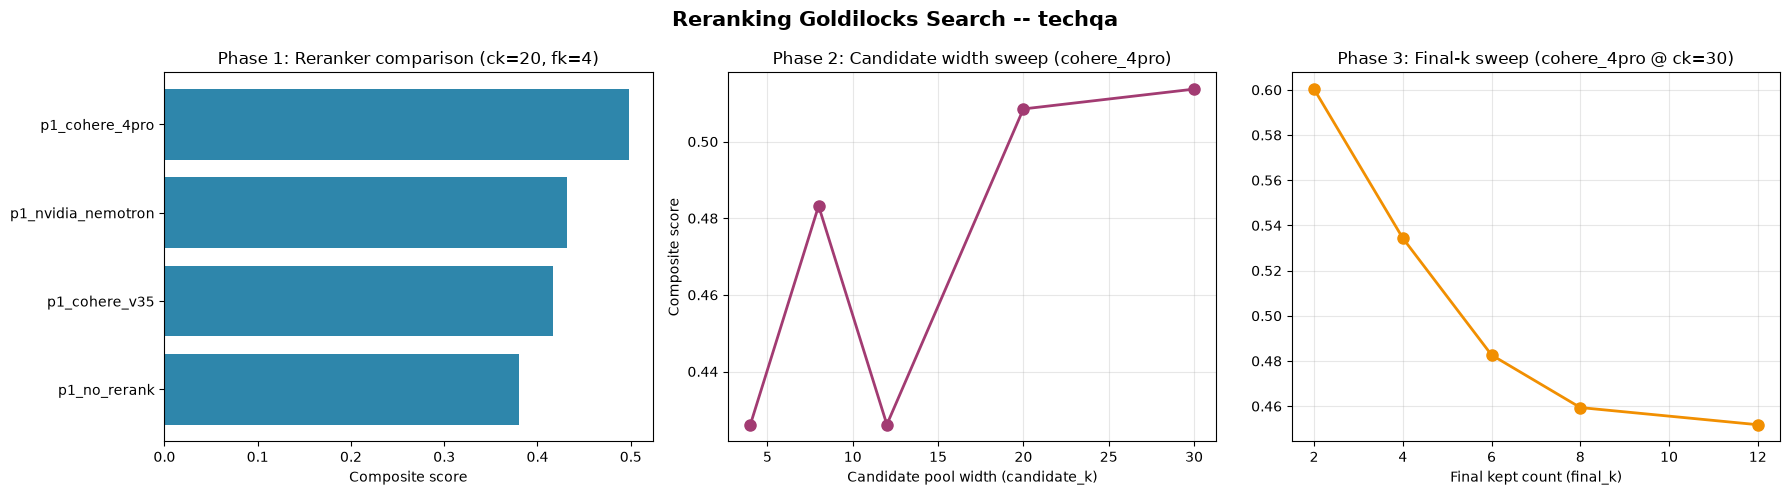

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Reranking Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title(f"Phase 1: Reranker comparison (ck={CANDIDATE_K_PHASE1}, fk={FINAL_K_PHASE1})")

p2_plot = phase2_df.dropna(subset=["composite"]).sort_values("candidate_k")
axes[1].plot(p2_plot["candidate_k"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("Candidate pool width (candidate_k)")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: Candidate width sweep ({phase2_method})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).sort_values("final_k")
axes[2].plot(p3_plot["final_k"], p3_plot["composite"], "o-", color="#F18F01", linewidth=2, markersize=8)
axes[2].set_xlabel("Final kept count (final_k)")
axes[2].set_title(f"Phase 3: Final-k sweep ({phase2_method} @ ck={phase2_winner_candidate_k})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [13]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "candidate_k", "final_k", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
no_rerank_row = phase1_df[phase1_df["config"] == "p1_no_rerank"].iloc[0]

print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS RERANKING CONFIG: {best['config']}")
print("=" * 100)
print(f"  Candidate pool width: {best['candidate_k']:.0f}")
print(f"  Final kept count:     {best['final_k']:.0f}")
print(f"  Context Relevance:    {best['context_relevance']:.4f}")
print(f"  Utilization:          {best['utilization']:.4f}")
print(f"  Completeness:         {best['completeness']:.4f}")
print(f"  Adherence:            {best['adherence']:.4f}")
print(f"  Composite:            {best['composite']:.4f}")
print(f"  Eval sample:          {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
if no_rerank_row["composite"] is not None and best["config"] != "p1_no_rerank":
    delta = best["composite"] - no_rerank_row["composite"]
    print(f"  vs. no-reranking control: {delta:+.4f} composite ({'worth adopting' if delta > 0 else 'no-reranking control still wins'})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
9,p3_cohere_4pro_ck30_fk2,30,2,20,0,0.621190,0.401025,0.635000,0.650000,0.600320
10,p3_cohere_4pro_ck30_fk4,30,4,20,0,0.460070,0.225895,0.512875,0.750000,0.534340
4,p2_cohere_4pro_ck30,30,4,20,0,0.426660,0.168130,0.394340,0.800000,0.513702
5,p2_cohere_4pro_ck20,20,4,20,0,0.427795,0.234275,0.524410,0.700000,0.508531
0,p1_cohere_4pro,20,4,20,0,0.422635,0.238245,0.465060,0.700000,0.498418
6,p2_cohere_4pro_ck8,8,4,20,0,0.435465,0.174435,0.514280,0.650000,0.483220
11,p3_cohere_4pro_ck30_fk6,30,6,20,0,0.353490,0.190355,0.569115,0.700000,0.482642
12,p3_cohere_4pro_ck30_fk8,30,8,20,0,0.225765,0.145030,0.640775,0.750000,0.459388
13,p3_cohere_4pro_ck30_fk12,30,12,20,0,0.156475,0.092485,0.571010,0.850000,0.451790
1,p1_nvidia_nemotron,20,4,20,0,0.458215,0.235995,0.521175,0.450000,0.431451



🏆 GOLDILOCKS RERANKING CONFIG: p3_cohere_4pro_ck30_fk2
  Candidate pool width: 30
  Final kept count:     2
  Context Relevance:    0.6212
  Utilization:          0.4010
  Completeness:         0.6350
  Adherence:            0.6500
  Composite:            0.6003
  Eval sample:          20/20 succeeded (failed: 0)
  vs. no-reranking control: +0.2199 composite (worth adopting)


### Caveats -- do not treat these exact numbers as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes some noise, but this is one
  dataset draw.
- **Chunking, retriever, and query transformation held constant** at `11`/`12`/`13`'s
  winning configs. Whether a different upstream pipeline changes which reranker (or whether
  reranking helps at all) is not explored here.
- **`query_llm` runs at temperature 0.7** for the HyDE retrieval string, same caveat as
  `13` -- a repeat run could shuffle close results even on the same fixed question set.
- **The OpenRouter rerank endpoint is a third-party dependency** with its own latency, cost,
  and availability characteristics not modeled by the composite score. A reranker that wins
  on quality but adds meaningful per-query latency may still not be worth adopting in
  production -- that tradeoff isn't captured in these numbers.
- **Phase 2/3 both hold candidate pool width and final_k semantics fixed at "top by hybrid
  score, then top by rerank score"** -- other reranking strategies (e.g. reranking multiple
  smaller shards independently, or blending rerank score with the original hybrid score)
  aren't tested.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`/`12`/`13` for comparability. The raw per-metric columns are in every results table if
  you want to re-rank by a different weighting or a single metric.
